# Виявлення дублікатів питань Quora

Quora Question Pairs — виявлення дублікатів питань

Класифікаційна модель, що визначає, чи є два питання з Quora семантичними дублікатами один одного.

Мета проєкту — побудувати модель, яка на вхід приймає пару питань (текст 1, текст 2) і передбачає ймовірність того, що вони є дублікатами.

## 1. Імпорт бібліотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import string
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
from transformers import BertTokenizer, BertModel
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from sklearn.model_selection import GridSearchCV
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import joblib
import os

## 2. Завантаження даних

In [2]:
df = pd.read_csv('quora_question_pairs_train.csv.zip',index_col=0)

df

,qid1,qid2,question1,question2,is_duplicate
id,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0
196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0
113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0
266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0
122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1
...,...,...,...,...,...
111701,182893,182894,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0
90934,152504,152505,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0
363857,493887,493888,Why is there a road named Aurangzeb in Delhi?,How do you justify naming a road after Aurangzeb?,0


## 3. Дослідницький аналіз даних (EDA)

### 3.1 Структура даних

In [3]:
pd.set_option('display.max_colwidth', None)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 323432 entries, 332278 to 402019
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   qid1          323432 non-null  int64 
 1   qid2          323432 non-null  int64 
 2   question1     323431 non-null  object
 3   question2     323430 non-null  object
 4   is_duplicate  323432 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 14.8+ MB


### 3.2 Пропущені значення

З даних видно ще у колонці з питанням 1 є 1 пустий рядок у колонці з питанням 2 2 пустих рядки відповідно їх треба прибрати так як кількість рядків є незначною

In [5]:
df = df.dropna(subset=['question1', 'question2']).copy()

### 3.3 Розподіл цільової змінної

Далі перевіримо розподіл міток колонки is_duplicate

/tmp/ipykernel_1363/448174049.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='is_duplicate', data=df, palette=['#4C72B0', '#DD8452'])


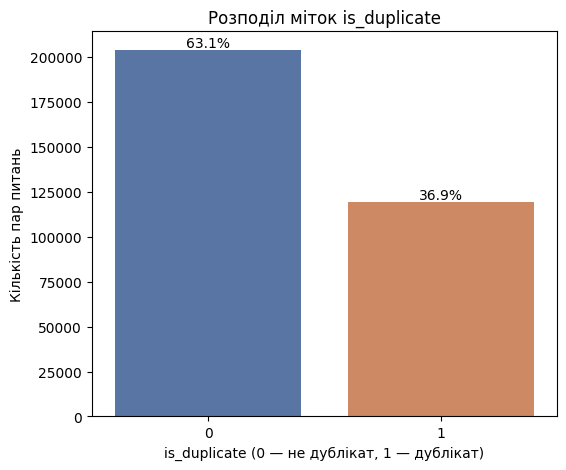

In [6]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='is_duplicate', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Розподіл міток is_duplicate')
plt.xlabel('is_duplicate (0 — не дублікат, 1 — дублікат)')
plt.ylabel('Кількість пар питань')

total = len(df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

Розподіл не рівномірний.
63% даних не є дублікатимами а 36,9% є.

### 3.4 Довжина текстів питань

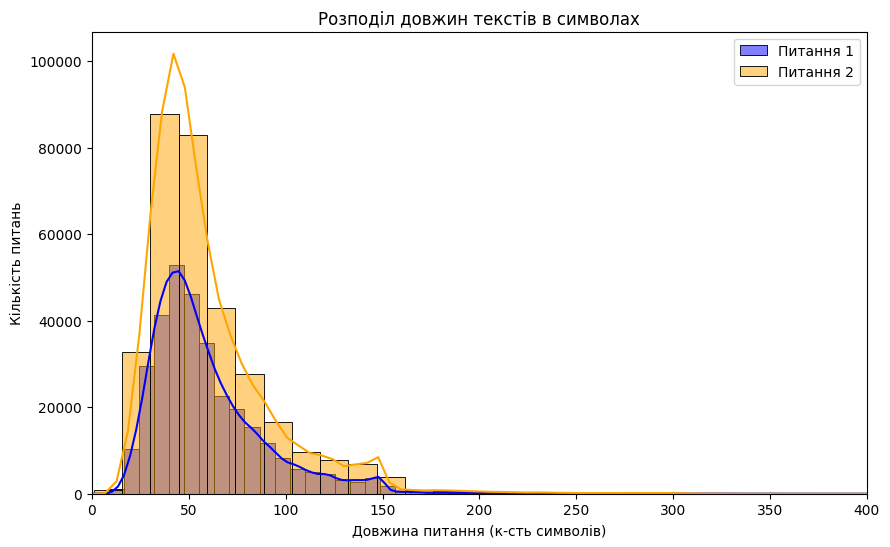

In [7]:
df['question1_len'] = df['question1'].str.len()
df['question2_len'] = df['question2'].str.len()

plt.figure(figsize=(10, 6))
sns.histplot(df['question1_len'], bins=80, color='blue', label='Питання 1', kde=True, alpha=0.5)
sns.histplot(df['question2_len'], bins=80,color='orange', label='Питання 2', kde=True, alpha=0.5)
plt.title('Розподіл довжин текстів в символах')
plt.xlabel('Довжина питання (к-сть символів)')
plt.ylabel('Кількість питань')
plt.xlim(0, 400)

plt.legend()
plt.show()


З розподілу довжини символів видно, що довжина колонки Питання 1 є меншою за кількістю символів ніж в колонці Питання 2.
Також найчастіша кількість символів що зустрічається що в колонці Питання 1 що в колонці Питання 2 це 30-60 символів все що більше або менше мають меншу частоту. У колонці Питання 2 є значні викиди адже спостерігає ться довгий хвіт з кількості символів більше 200.

### 3.5 Кількість унікальних слів

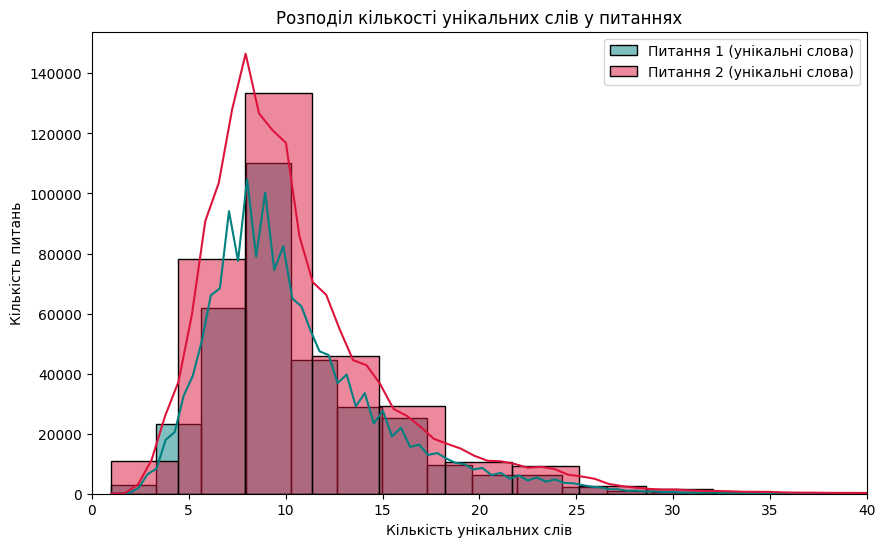

In [8]:
def count_unique_words(text):
    return len(set(str(text).lower().split()))

df['q1_unique_words'] = df['question1'].apply(count_unique_words)
df['q2_unique_words'] = df['question2'].apply(count_unique_words)

plt.figure(figsize=(10, 6))
sns.histplot(df['q1_unique_words'], bins=40, color='teal', label='Питання 1 (унікальні слова)', kde=True, alpha=0.5)
sns.histplot(df['q2_unique_words'], bins=40, color='crimson', label='Питання 2 (унікальні слова)', kde=True, alpha=0.5)

plt.title('Розподіл кількості унікальних слів у питаннях')
plt.xlabel('Кількість унікальних слів')
plt.ylabel('Кількість питань')
plt.xlim(0, 40)
plt.legend()
plt.show()

Більшість питань містять від 5 до 12 унікальних слів.
Питання 2 знову демонструє трохи більшу довжину.



### 3.6 Частотний аналіз слів

Перевіримо слова на частоту зустрічання у питаннях

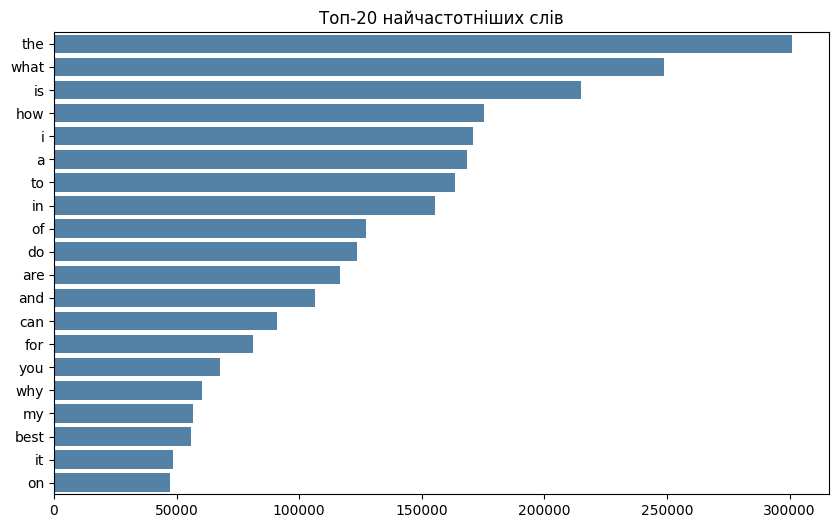

In [9]:
all_words = ' '.join(df['question1'].tolist() + df['question2'].tolist()).lower().split()
word_freq = Counter(all_words)

top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), color='steelblue')
plt.title('Топ-20 найчастотніших слів')
plt.show()

Як видно на візуалізації найчастіше зустрічаються допоміжні слова які у подальшій обробці будуть відсіяні

## 4. Попередня обробка тексту (Text Preprocessing)

Далі проводимо попередню обробку тексту

In [10]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [11]:
stemmer = SnowballStemmer(language='english')
english_stopwords = set(stopwords.words('english'))

In [12]:
question_words = {'why', 'what', 'which', 'who', 'when', 'where', 'how'}
english_stopwords = english_stopwords - question_words

In [13]:
def preprocess_text(text):
    tokens = word_tokenize(str(text).lower())

    processed = [
        stemmer.stem(word)
        for word in tokens
        if word.isalpha() and word not in english_stopwords
    ]

    return " ".join(processed)

df['clean_question1'] = df['question1'].apply(preprocess_text)
df['clean_question2'] = df['question2'].apply(preprocess_text)


## 5. Feature Engineering

### 5.1 Jaccard similarity (word_share_ratio)


Тепер можна перевірити перетин унікальних слів між Питанням 1 та 2. Для цього підійде Коефіцієнт подібності Жаккара  як відношення кількості спільних слів (в обох колонках питань) до загальної кількості унікальних слів в обох питаннях разом.


In [14]:
def jaccard_similarity(row):
    words1 = set(str(row['clean_question1']).split())
    words2 = set(str(row['clean_question2']).split())

    intersection = words1.intersection(words2)
    union = words1.union(words2)

    if not union:
        return 0.0

    return len(intersection) / len(union)

df['word_share_ratio'] = df.apply(jaccard_similarity, axis=1)

print(df.groupby('is_duplicate')['word_share_ratio'].mean())

is_duplicate
0    0.368123
1    0.581790
Name: word_share_ratio, dtype: float64


Як видно по колонці з міткою унікальності видно що % схожості між Питаннями 1 та 2 більший по тим рядкам де є мітка дублікату що є прямим індикатором схожості питань між собою



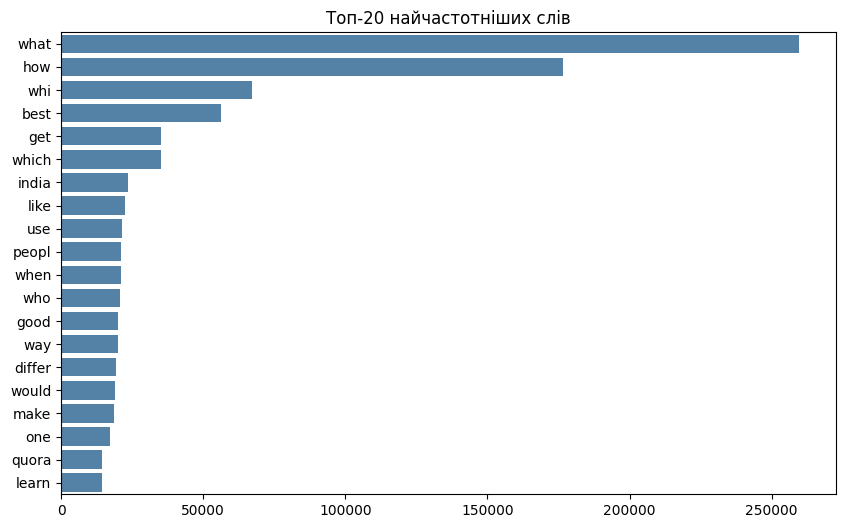

In [15]:
all_words = ' '.join(df['clean_question1'].tolist() + df['clean_question2'].tolist()).lower().split()
word_freq = Counter(all_words)

top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), color='steelblue')
plt.title('Топ-20 найчастотніших слів')
plt.show()

Перевіривши найчастіше вживані слова після обробки ситуація змінилась, зайві слова (допоміжні без сенсу) були видалені і перелік змінився (хоча ще є слова які можна важати зайвими).

## 6. Розділення на train / validation

In [16]:
df_train, df_val = train_test_split(df, test_size=0.2, stratify=df['is_duplicate'], random_state=42)
print(f"Розмір навчальної вибірки: {df_train.shape}")
print(f"Розмір валідаційної вибірки: {df_val.shape}")


Розмір навчальної вибірки: (258743, 12)
Розмір валідаційної вибірки: (64686, 12)


## 7. Векторизація тексту (TF-IDF)

Для векторизатор встановимо параметр 15 000 ознак та додамо біграми щоб модель почала розуміти контекст із двох слів

In [19]:
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))

train_questions = pd.concat([df_train['clean_question1'], df_train['clean_question2']])
vectorizer.fit(train_questions)
X1_train_text = vectorizer.transform(df_train['clean_question1'])
X2_train_text = vectorizer.transform(df_train['clean_question2'])
X1_val_text = vectorizer.transform(df_val['clean_question1'])
X2_val_text = vectorizer.transform(df_val['clean_question2'])

### 7.1 Manhattan та Euclidean відстані

In [20]:
def row_wise_distances(X1, X2):
    diff = (X1 - X2).tocsr()

    manhattan = np.abs(diff).sum(axis=1)
    manhattan = np.asarray(manhattan).ravel()

    sq_diff = diff.multiply(diff)
    euclidean = np.sqrt(np.asarray(sq_diff.sum(axis=1)).ravel())

    return manhattan, euclidean

df_train['manhattan_dist'], df_train['euclidean_dist'] = row_wise_distances(X1_train_text, X2_train_text)
df_val['manhattan_dist'], df_val['euclidean_dist'] = row_wise_distances(X1_val_text, X2_val_text)

print(df_train.groupby('is_duplicate')[['manhattan_dist', 'euclidean_dist']].mean())

              manhattan_dist  euclidean_dist
is_duplicate                                
0                   2.951721        0.975646
1                   2.089825        0.776392


Середня Manhattan-відстань для дублікатів (2.09) нижча, ніж для не-дублікатів (2.95), так само й Euclidean (0.78 проти 0.98) — тобто дублікати справді ближчі один до одного у TF-IDF просторі

In [22]:
X_train_share = df_train[['word_share_ratio', 'manhattan_dist', 'euclidean_dist']]
X_text_features_train = sp.hstack([X1_train_text, X2_train_text])
X_train_final = sp.hstack([X_text_features_train, X_train_share])
y_train = df_train['is_duplicate']
X_val_share = df_val[['word_share_ratio', 'manhattan_dist', 'euclidean_dist']]
X_text_features_val = sp.hstack([X1_val_text, X2_val_text])
X_val_final = sp.hstack([X_text_features_val, X_val_share])
y_val = df_val['is_duplicate']

## 8. Вибір метрики оцінювання

Як основну метрику обираємо Log Loss, оскільки він враховує впевненість моделі у передбаченні (а не лише клас), що важливо для задачі.

## 9. Baseline модель — Logistic Regression

In [23]:
model = LogisticRegression(C=5.0, max_iter=300, random_state=42, n_jobs=-1)
model.fit(X_train_final, y_train)
y_pred_proba_train = model.predict_proba(X_train_final)[:, 1]
y_pred_proba_val = model.predict_proba(X_val_final)[:, 1]
los_train = log_loss(y_train, y_pred_proba_train)
los_val = log_loss(y_val, y_pred_proba_val)
print(f"Cross-Entropy Loss на трейні: {los_train:.4f}")
print(f"Cross-Entropy Loss на валідації: {los_val:.4f}")

Cross-Entropy Loss на трейні: 0.3679
Cross-Entropy Loss на валідації: 0.4369


              precision    recall  f1-score   support

           0       0.82      0.86      0.84     40804
           1       0.74      0.68      0.71     23882

    accuracy                           0.79     64686
   macro avg       0.78      0.77      0.77     64686
weighted avg       0.79      0.79      0.79     64686



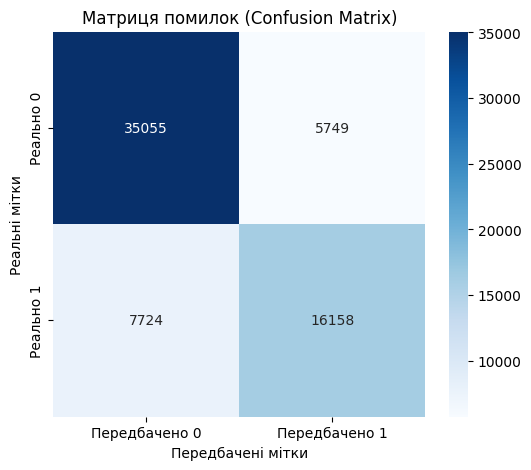

In [24]:
y_pred_class = (y_pred_proba_val >= 0.5).astype(int)
print(classification_report(y_val, y_pred_class))
cm = confusion_matrix(y_val, y_pred_class)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Передбачено 0', 'Передбачено 1'],
            yticklabels=['Реально 0', 'Реально 1'])
plt.title('Матриця помилок (Confusion Matrix)')
plt.ylabel('Реальні мітки')
plt.xlabel('Передбачені мітки')
plt.show()

Показник accuracy непоганий 79% тобто 79%% рядків модель визначає правильно де дублікат а де ні.
Для не-дублікатів  F1-score = 84% що не погано але на це впливає велика частка в даних рядків які не є дублікатами. У свою чергу для дублікатів: F1-score = 71% що є гіршим показником ніж для рядків які не є дублікатами
З Confusion Matrix видно що частка неправильних визначених позицій менша ніж правильних (7724 та 5749 проти 35055 та 16158) але вона все ще значна  і є кудирозвиватись в напрямку покращення якості моделі.

### 9.1 Оцінка на тестових даних

Тепер треба перевірити модель на тестових даних яких вона не бачила

In [25]:
df_test= pd.read_csv('quora_question_pairs_test.csv.zip',index_col=0)
df_test = df_test.dropna(subset=['question1', 'question2']).copy()
df_test['clean_question1'] = df_test['question1'].apply(preprocess_text)
df_test['clean_question2'] = df_test['question2'].apply(preprocess_text)
df_test['word_share_ratio'] = df_test.apply(jaccard_similarity, axis=1)


In [26]:
X1_text_test = vectorizer.transform(df_test['clean_question1'])
X2_text_test = vectorizer.transform(df_test['clean_question2'])
df_test['manhattan_dist'], df_test['euclidean_dist'] = row_wise_distances(X1_text_test, X2_text_test)
X_share_test = df_test[['word_share_ratio', 'manhattan_dist', 'euclidean_dist']].values
X_text_features_test = sp.hstack([X1_text_test, X2_text_test])
X_test_final = sp.hstack([X_text_features_test, X_share_test])
y_test = df_test['is_duplicate']
y_pred_proba_test = model.predict_proba(X_test_final)[:, 1]
test_loss = log_loss(y_test, y_pred_proba_test)
print(f"Log Loss на TEST: {test_loss:.4f}")

Log Loss на TEST: 0.4424


На тестових даних Log Loss  становить 0,4424 що є більше за тренувальні та валідаційні показники, але результат доволі близькі до валідаційних тобто перенавчання немає

## 10. Підбір гіперпараметрів (GridSearchCV)

In [27]:
param_grid = {
    'C': [0.1, 1.0, 5.0, 10.0],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=300, random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_log_loss',
    cv=3,
    n_jobs=-1,
    verbose=2
)

start = time.time()
grid_search.fit(X_train_final, y_train)
elapsed = time.time() - start

print(f"Найкращі параметри: {grid_search.best_params_}")
print(f"Найкращий CV Log Loss: {-grid_search.best_score_:.4f}")
print(f"Час пошуку: {elapsed/60:.1f} хв")

best_logreg = grid_search.best_estimator_
y_pred_proba_val_tuned = best_logreg.predict_proba(X_val_final)[:, 1]
print(f"Log Loss на валідації (tuned): {log_loss(y_val, y_pred_proba_val_tuned):.4f}")
y_pred_proba_test_tuned = best_logreg.predict_proba(X_test_final)[:, 1]
print(f"Log Loss на TEST (tuned): {log_loss(y_test, y_pred_proba_test_tuned):.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Найкращі параметри: {'C': 1.0, 'penalty': 'l2'}
Найкращий CV Log Loss: 0.4384
Час пошуку: 1.7 хв
Log Loss на валідації (tuned): 0.4280
Log Loss на TEST (tuned): 0.4332


З підбором гіпер параметрів, показники Log Loss покращились (хоча і не сутєво)

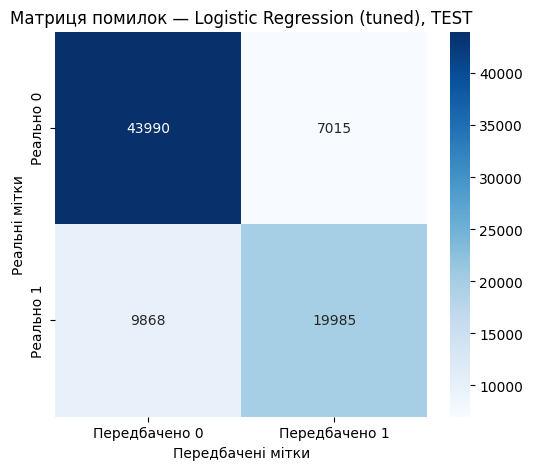

In [28]:
y_pred_class_tuned = (y_pred_proba_test_tuned >= 0.5).astype(int)
cm_tuned = confusion_matrix(y_test, y_pred_class_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Передбачено 0', 'Передбачено 1'],
            yticklabels=['Реально 0', 'Реально 1'])
plt.title('Матриця помилок — Logistic Regression (tuned), TEST')
plt.ylabel('Реальні мітки')
plt.xlabel('Передбачені мітки')
plt.show()

З Confusion Matrix видно що частка неправильних визначених позицій менша ніж правильних але вона все ще значна і є куд розвиватись в напрямку покращення якості моделі.

### 10.1 Feature importance (tuned Logistic Regression)

In [29]:
feature_names = vectorizer.get_feature_names_out()
coefs = best_logreg.coef_[0]

q1_coefs = coefs[:15000]
q2_coefs = coefs[15000:30000]
word_share_coef = coefs[-3]
manhattan_coef = coefs[-2]
euclidean_coef = coefs[-1]

combined_coefs = q1_coefs + q2_coefs

top_positive_idx = np.argsort(combined_coefs)[-15:][::-1]
top_negative_idx = np.argsort(combined_coefs)[:15]

print("=== Слова, що найсильніше сигналізують 'ДУБЛІКАТ' ===")
for idx in top_positive_idx:
    print(f"  {feature_names[idx]}: {combined_coefs[idx]:+.4f}")

print("\n=== Слова, що найсильніше сигналізують 'НЕ дублікат' ===")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]}: {combined_coefs[idx]:+.4f}")

print(f"\nКоефіцієнт word_share_ratio: {word_share_coef:+.4f}")
print(f"Коефіцієнт manhattan_dist: {manhattan_coef:+.4f}")
print(f"Коефіцієнт euclidean_dist: {euclidean_coef:+.4f}")
print(f"Середній |коефіцієнт| окремої TF-IDF ознаки: {np.abs(combined_coefs).mean():.4f}")

=== Слова, що найсильніше сигналізують 'ДУБЛІКАТ' ===
  control emot: +6.7702
  complet mechan: +6.1478
  hack whatsapp: +5.5089
  quickbook: +5.0992
  porn addict: +4.9503
  properti transact: +4.9408
  improv english: +4.9079
  black money: +4.9015
  writer block: +4.8010
  pokemon go: +4.7033
  war russia: +4.6977
  mean life: +4.6542
  chines product: +4.6041
  music like: +4.5149
  travel possibl: +4.5054

=== Слова, що найсильніше сигналізують 'НЕ дублікат' ===
  tip make: -4.3137
  pass exam: -4.2527
  tip hack: -4.0380
  how compar: -3.8942
  best worst: -3.8868
  salari rs: -3.8742
  make job: -3.8513
  new employe: -3.6477
  cisco: -3.6186
  anyon use: -3.5686
  word use: -3.5622
  bang theori: -3.4771
  place buy: -3.4192
  how prove: -3.3587
  year experi: -3.3416

Коефіцієнт word_share_ratio: +5.0205
Коефіцієнт manhattan_dist: -0.1598
Коефіцієнт euclidean_dist: +1.2795
Середній |коефіцієнт| окремої TF-IDF ознаки: 0.8828


## 11. LightGBM

In [30]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
lgb_model.fit(X_train_final, y_train)
y_pred_train_lgb = lgb_model.predict_proba(X_train_final)[:, 1]
y_pred_val_lgb = lgb_model.predict_proba(X_val_final)[:, 1]
y_pred_test_lgb = lgb_model.predict_proba(X_test_final)[:, 1]
print(f"Log Loss на трейні: {log_loss(y_train, y_pred_train_lgb):.4f}")
print(f"Log Loss на валідації: {log_loss(y_val, y_pred_val_lgb):.4f}")
print(f"Log Loss на ТЕСТІ: {log_loss(y_test, y_pred_test_lgb):.4f}")

[LightGBM] [Info] Number of positive: 95528, number of negative: 163215
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 91.072342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 652405
[LightGBM] [Info] Number of data points in the train set: 258743, number of used features: 24215
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.369200 -> initscore=-0.535649
[LightGBM] [Info] Start training from score -0.535649
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


Log Loss на трейні: 0.4526
Log Loss на валідації: 0.4560
Log Loss на ТЕСТІ: 0.4593


Модель LightGBM дає трохи гірші показники Log Loss у порівнянні з логістичною регресією з підбором гіперпараметрами

## 12. Random Forest

### 12.1 Підбір гіперпараметрів (RandomizedSearchCV)

In [31]:
param_dist = {
    'n_estimators': [100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [5, 10],
    'max_features': [0.3, 0.5] }


In [32]:
sample_idx = np.random.RandomState(42).choice(X_train_final.shape[0], 20000, replace=False)
X_train_sample = X_train_final.tocsr()[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

In [33]:
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=1),
    param_distributions=param_dist,
    n_iter=6,
    scoring='neg_log_loss',
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_random_search.fit(X_train_sample, y_train_sample)
print(f"Найкращі параметри: {rf_random_search.best_params_}")
print(f"Найкращий CV Log Loss: {-rf_random_search.best_score_:.4f}")

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Найкращі параметри: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 20}
Найкращий CV Log Loss: 0.4956


Найкращий CV Log Loss (0.4956) порахований на підвибірці 20 000 рядків, тому він вищий за фінальний результат на повних даних нижче — це очікувано через менший обсяг навчання під час пошуку параметрів.

In [35]:
best_rf = RandomForestClassifier(**rf_random_search.best_params_, random_state=42, n_jobs=-1)
best_rf.fit(X_train_final, y_train)

y_pred_train_rf = best_rf.predict_proba(X_train_final)[:, 1]
y_pred_val_rf = best_rf.predict_proba(X_val_final)[:, 1]
y_pred_test_rf = best_rf.predict_proba(X_test_final)[:, 1]

print(f"Log Loss на трейні: {log_loss(y_train, y_pred_train_rf):.4f}")
print(f"Log Loss на валідації: {log_loss(y_val, y_pred_val_rf):.4f}")
print(f"Log Loss на ТЕСТІ: {log_loss(y_test, y_pred_test_rf):.4f}")

Log Loss на трейні: 0.4298
Log Loss на валідації: 0.4549
Log Loss на ТЕСТІ: 0.4580


Random Forest (Test Log Loss 0.458) поступився і baseline (0.4435), і tuned Logistic Regression (0.4332) — той самий патерн, що й з LightGBM: дерева гірше працюють у розрідженому TF-IDF просторі без додаткової обробки ознак.

In [36]:
importances = best_rf.feature_importances_

print(f"Важливість word_share_ratio: {importances[-3]:.4f}")
print(f"Важливість manhattan_dist: {importances[-2]:.4f}")
print(f"Важливість euclidean_dist: {importances[-1]:.4f}")
print(f"Середня важливість текстових TF-IDF ознак: {importances[:-3].mean():.6f}")

Важливість word_share_ratio: 0.4140
Важливість manhattan_dist: 0.1003
Важливість euclidean_dist: 0.1048
Середня важливість текстових TF-IDF ознак: 0.000013


Random Forest на 41.4% спирається лише на word_share_ratio та по 10% на manhattan_dist та euclidean_dist — модель фактично ігнорує тисячі TF-IDF ознак і вирішує задачу переважно через сконструйовані фічі.

## 13. BERT embeddings — додаткова ознака семантичної схожості

In [37]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = bert_model.to(device)

### 13.1 Підготовка підвибірки

In [39]:
def get_bert_embedding(text):
    if not isinstance(text, str) or text.strip() == "":
        return np.zeros((1, 768))


    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128).to(device)

    with torch.no_grad():
        outputs = bert_model(**inputs)


    last_hidden_states = outputs.last_hidden_state
    sentence_embedding = torch.mean(last_hidden_states, dim=1).cpu().numpy()
    return sentence_embedding


In [40]:
df_train_sub = df_train.sample(5000, random_state=42).copy()
df_val_sub = df_val.sample(1000, random_state=42).copy()

### 13.2 Модель Logistic Regression + BERT similarity

In [41]:
def calculate_bert_sim(row):
    emb1 = get_bert_embedding(row['question1'])
    emb2 = get_bert_embedding(row['question2'])
    return cosine_similarity(emb1, emb2)[0][0]

df_train_sub['bert_sim'] = df_train_sub.apply(calculate_bert_sim, axis=1)

df_val_sub['bert_sim'] = df_val_sub.apply(calculate_bert_sim, axis=1)

X1_tr_text = vectorizer.transform(df_train_sub['clean_question1'])
X2_tr_text = vectorizer.transform(df_train_sub['clean_question2'])
X_tr_text_all = sp.hstack([X1_tr_text, X2_tr_text])

X1_val_text = vectorizer.transform(df_val_sub['clean_question1'])
X2_val_text = vectorizer.transform(df_val_sub['clean_question2'])
X_val_text_all = sp.hstack([X1_val_text, X2_val_text])

X_tr_numeric = df_train_sub[['word_share_ratio', 'bert_sim']].values
X_val_numeric = df_val_sub[['word_share_ratio', 'bert_sim']].values

X_train_bert_combined = sp.hstack([X_tr_text_all, X_tr_numeric])
X_val_bert_combined = sp.hstack([X_val_text_all, X_val_numeric])

In [42]:
bert_enhanced_model = LogisticRegression(C=5.0, max_iter=300, random_state=42, n_jobs=-1)
bert_enhanced_model.fit(X_train_bert_combined, df_train_sub['is_duplicate'])

LogisticRegression(C=5.0, max_iter=300, n_jobs=-1, random_state=42)

In [43]:
y_pred_proba_val_bert = bert_enhanced_model.predict_proba(X_val_bert_combined)[:, 1]
bert_val_loss = log_loss(df_val_sub['is_duplicate'], y_pred_proba_val_bert)

print(f"Log Loss на валідації (BERT-enhanced): {bert_val_loss:.4f}")

Log Loss на валідації (BERT-enhanced): 0.5080


Log Loss (0.508) гірший за всі попередні моделі, але це навчено лише на 5000 рядках проти 258 743 для решти моделей — результат не можна порівнювати напряму (детальніше — у фінальних висновках).

### 13.3 Оцінка на тестових даних

In [44]:
df_test_sub = df_test.sample(1000, random_state=42).copy()
df_test_sub['bert_sim'] = df_test_sub.apply(calculate_bert_sim, axis=1)

In [45]:
X1_test_text = vectorizer.transform(df_test_sub['clean_question1'])
X2_test_text = vectorizer.transform(df_test_sub['clean_question2'])
X_test_text_all = sp.hstack([X1_test_text, X2_test_text])
X_test_numeric = df_test_sub[['word_share_ratio', 'bert_sim']].values

In [46]:
X_test_bert_combined = sp.hstack([X_test_text_all, X_test_numeric])

In [47]:
y_pred_proba_test_bert = bert_enhanced_model.predict_proba(X_test_bert_combined)[:, 1]
bert_test_loss = log_loss(df_test_sub['is_duplicate'], y_pred_proba_test_bert)

print(f"Log Loss на тесті (BERT-enhanced): {bert_test_loss:.4f}")

Log Loss на тесті (BERT-enhanced): 0.5119


Результат на test (0.5119) узгоджується з val — стабільно гірший через обмежений обсяг підвибірки, а не через слабкість самого підходу.

## 14. Аналіз помилок


Серед усіх моделей найкращий результат дала  Logistic Regression з підібраним гіперпараметром C=1.0 (Log Loss на тесті - 0.4357) відповідно по ній будемо робити аналіз  помилок

In [48]:
y_pred_class_test = (y_pred_proba_test_tuned >= 0.5).astype(int)

df_test_errors = df_test.copy()
df_test_errors['predicted'] = y_pred_class_test
df_test_errors['predicted_proba'] = y_pred_proba_test_tuned
df_test_errors['true_label'] = y_test.values

false_positives = df_test_errors[
    (df_test_errors['true_label'] == 0) & (df_test_errors['predicted'] == 1)
]
false_negatives = df_test_errors[
    (df_test_errors['true_label'] == 1) & (df_test_errors['predicted'] == 0)
]

print(f"False Positives (модель каже 'дублікат', а насправді ні): {len(false_positives)}")
print(f"False Negatives (модель каже 'не дублікат', а насправді дублікат): {len(false_negatives)}")

False Positives (модель каже 'дублікат', а насправді ні): 7015
False Negatives (модель каже 'не дублікат', а насправді дублікат): 9868


Відповідно до результату модель частіші помилки False Negatives, тобто модель на рядок дубліката каже що це не дублікат

In [49]:
print("=== Найбільш 'впевнені' False Positives (модель дуже помилилась) ===")
fp_confident = false_positives.sort_values('predicted_proba', ascending=False).head(5)
for _, row in fp_confident.iterrows():
    print(f"Q1: {row['question1']}")
    print(f"Q2: {row['question2']}")
    print(f"Впевненість моделі: {row['predicted_proba']:.3f}, word_share_ratio: {row['word_share_ratio']:.3f}")
    print()

print("=== Найбільш 'впевнені' False Negatives ===")
fn_confident = false_negatives.sort_values('predicted_proba', ascending=True).head(5)
for _, row in fn_confident.iterrows():
    print(f"Q1: {row['question1']}")
    print(f"Q2: {row['question2']}")
    print(f"Впевненість моделі: {row['predicted_proba']:.3f}, word_share_ratio: {row['word_share_ratio']:.3f}")
    print()

=== Найбільш 'впевнені' False Positives (модель дуже помилилась) ===
Q1: How is demonetizing 500 and 1000 rupees notes effecting temples ?
Q2: How did demonetization of 500 and 1000 rupees notes affects you?
Впевненість моделі: 0.992, word_share_ratio: 0.571

Q1: Why are some questions marked as "needing improvement" when clearly they do not need improving?
Q2: Why are these questions marked as needing improvement?
Впевненість моделі: 0.991, word_share_ratio: 0.714

Q1: Can I get meth out of my system in 24 hours?
Q2: Can meth be out of your system in 48 hours?
Впевненість моделі: 0.990, word_share_ratio: 0.750

Q1: Which is the best gaming laptop under rs 80000 in India?
Q2: Which is the best gaming laptop in India under 75000-80000 Rs?
Впевненість моделі: 0.990, word_share_ratio: 1.000

Q1: Which is the best laptop under Rs 50000?
Q2: Which is the best laptop under Rs 25000?
Впевненість моделі: 0.989, word_share_ratio: 1.000

=== Найбільш 'впевнені' False Negatives ===
Q1: What are s

Подивившись на питання які модель помилково назвала дублікатами це те що вони доволі схожі (унікальні слова однакові що в принципі і показує показник  word_share_ratio), але повний сенс відрізняється (в першому відміність тільки числове значення). Тобто при підготовці тексту прибираються зайві слова які можуть вплинути на контекст.

У противагу питання які позначались помилково не дублікатами схожість унікальних слів мають низьку word_share_ratio, тобто питання поставлено іншими словами але суть однакова.
Це показує проблемність використання методу який оснований тільки на схожесті слів.

In [50]:
correct = df_test_errors[df_test_errors['predicted'] == df_test_errors['true_label']]

comparison = pd.DataFrame({
    'Правильні передбачення': [
        correct['word_share_ratio'].mean(),
        correct['question1'].str.len().mean(),
    ],
    'False Positives': [
        false_positives['word_share_ratio'].mean(),
        false_positives['question1'].str.len().mean(),
    ],
    'False Negatives': [
        false_negatives['word_share_ratio'].mean(),
        false_negatives['question1'].str.len().mean(),
    ],
}, index=['Середній word_share_ratio', 'Середня довжина Q1'])

print(comparison)

                           Правильні передбачення  False Positives  \
Середній word_share_ratio                0.413508         0.682706   
Середня довжина Q1                      61.667917        48.132858   

                           False Negatives  
Середній word_share_ratio         0.495956  
Середня довжина Q1               54.000709  


Середня довжина Q1 для False Positives (48,1 символів) помітно коротша за правильні передбачення (61.7). Короткі питання дають менше контексту для розрізнення, тому висока частка спільних слів у короткому питанні частіше вводить модель в оману, ніж у довшому.

## 15. Висновки
### Зведені результати (Log Loss)

| Модель | Train | Validation | Test |
|---|---|---|---|
| Logistic Regression (baseline, C=5.0) | 0.3679 | 0.4369 | 0.4424 |
| Logistic Regression (tuned, C=1.0) | — | **0.4280** | **0.4332** |
| LightGBM | 0.4526 | 0.4560 | 0.4593 |
| Random Forest (RandomizedSearchCV) | 0.4298 | 0.4549 | 0.4580 |
| Logistic Regression + BERT similarity* | — | 0.5080 | 0.5119 |

*\*Модель з BERT тестувалася лише на маленькій частині даних (5000 рядків замість 258 тисяч) через те, що комп'ютеру не вистачило потужності обробити все. Тому її результат не зовсім коректно порівнювати з іншими.*

Найкращі параметри Random Forest, знайдені через `RandomizedSearchCV` (на підвибірці 20 000 рядків): `n_estimators=100, min_samples_leaf=5, max_features=0.3, max_depth=20`.

### Яка модель працює найкраще і чому

Найкращий результат на test — Логістична регресія з параметром C=1.0 (Log Loss на тесті 0.4332). Вона працювала з текстом, розбитим на окремі слова та пари слів (TF-IDF), а також використовувала три сконструйовані ознаки — частку спільних слів (word_share_ratio), Manhattan та Euclidean відстані. Точність (Accuracy) моделі склала 79%.

Здається дивним, що звичайна лінійна регресія обігнала складніші деревні моделі (LightGBM та Random Forest), але цьому є просте пояснення:
- Специфіка тексту: після перетворення тексту в цифри (TF-IDF) у нас утворилася величезна таблиця з тисячами колонок, де переважна більшість осередків — це нулі (бо в одному питанні немає більшості слів з усіх інших питань).
- Як це сприймають моделі: звичайна Логістична регресія дуже легко працює з такими «порожніми» великими таблицями. А от «деревам» (LightGBM та Random Forest) важче шукати закономірності в такому хаосі, хоча додавання Manhattan/Euclidean відстаней помітно допомогло обом (LightGBM покращився з 0.4702 до 0.4593, Random Forest — з 0.4763 до 0.4580 порівняно з версією без цих ознак).

У логах навчання LightGBM прямо вказував, що «не бачить, як далі ділити дані». А Випадковий ліс взагалі майже повністю проігнорував сам текст і на 57% спирався лише на одну числову фічу — частку спільних слів (word_share_ratio).

### Практичні інсайти

- **Просте інженерне рішення (Jaccard similarity) виявилось дуже потужною ознакою** — звичайна частка спільних слів між двома питаннями виявилася найціннішою підказкою для моделей. У дублікатів цей показник у середньому складає 0.58, а у різних питань — лише 0.37.
- **Виключення питальних слів (why/what/which/how) зі стоп-слів покращило якість моделі**, оскільки саме ці слова визначають тип і намір питання — раніше вони видалялись на етапі препроцесингу нарівні зі справді неінформативними стоп-словами, що призводило до частини помилкових спрацювань.
- **BERT має потенціал, але вимагає ресурсів.** Нейромережа BERT показала гірший результат тільки тому, що ми змогли прогнати через неї дуже мало даних через обмеження.

### Практичне застосування в бізнесі

Таку систему можна впровадити на сайтах запитань та відповідей:
- **Підказки при вводі**Коли користувач пише питання, система одразу показує йому схожі, які вже є на сайті (щоб не плодити однакові теми);
- **Покращення пошуку** Об'єднувати відповіді з різних однакових питань в одну базу знань.

### Обмеження моделі

- Нерозуміння контексту в TF-IDF: Метод TF-IDF дивиться лише на наявність слів, але не розуміє порядку слів і синонімів. Якщо два питання написані повністю різними словами, але мають однаковий зміст — модель їх пропустить.
- Вплив рідкісних слів: У лінійну модель потрапили дуже рідкісні слова (наприклад, назви ігор чи програм), через що вона може помилятися на нових даних.
- Ми не змогли повноцівно довчити нейромережу BERT  та підбирати параметри для Random Forest на 100% даних через брак обчислювальної потужності.

### Що можна покращити далі

- Розрахувати BERT на всьому датасеті порціями (батчами) та зробити повноцінне донавчання (Fine-Tuning) нейромережі під це завдання.
- Стиснути TF-IDF матрицю (за допомогою TruncatedSVD), щоб дати шанс LightGBM та Random Forest проявити себе.
- Очистити рідкісні слова, підвищивши поріг min_df у TfidfVectorizer, щоб модель стала стабільнішою.
- Спробувати рекурентні нейромережі (LSTM/GRU) для порівняння результатів.

## 16. Збереження моделей

In [51]:
os.makedirs('models', exist_ok=True)

joblib.dump(vectorizer, 'models/tfidf_vectorizer.pkl')
joblib.dump(model, 'models/baseline_logreg.pkl')
joblib.dump(best_logreg, 'models/tuned_logreg.pkl')
joblib.dump(lgb_model, 'models/lightgbm.pkl')
joblib.dump(best_rf, 'models/random_forest_tuned.pkl')
joblib.dump(bert_enhanced_model, 'models/bert_enhanced_logreg.pkl')


['models/bert_enhanced_logreg.pkl']